# 6.1 — Vasicek y Hull-White: precios de bono analíticos, fit exacto a la curva

Todo M5 construyó la curva de descuento a partir de instrumentos de hoy. M6 da el paso siguiente: modelar cómo esa curva **evoluciona en el tiempo**, para poder valuar cualquier cosa cuyo payoff dependa de tasas futuras — caps, swaptions, exposiciones de contraparte. La familia más simple posible es modelar directamente la **tasa corta** $r_t$ con una única fuente de aleatoriedad, y del proceso de $r_t$ derivar el precio de **todos** los bonos simultáneamente.

Este notebook deriva Vasicek (1977) — el proceso de Ornstein-Uhlenbeck que 1.4 ya simuló, ahora leído como tasa corta — y Hull-White (1990), su generalización con reversión a un nivel **dependiente del tiempo**, diseñada específicamente para resolver el defecto estructural de Vasicek: con parámetros constantes, el modelo genera una familia de curvas de sólo un puñado de formas posibles, y **no puede** — no es cuestión de calibrar mejor, es una limitación estructural — reproducir una curva de mercado arbitraria en todos sus vencimientos simultáneamente.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from qflib.mc import ou_paths
from qflib.market import nelson_siegel_df
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

r0, kappa, theta, sigma = 0.04, 0.3, 0.045, 0.015
T_test = 5.0

print(f"Parametros Vasicek de ejemplo: r0={r0}, kappa={kappa}, theta={theta}, sigma={sigma}")
print(f"Curva de mercado 'verdadera': Nelson-Siegel de siempre, P(0,5) = {nelson_siegel_df(5.0):.6f}")

Parametros Vasicek de ejemplo: r0=0.04, kappa=0.3, theta=0.045, sigma=0.015
Curva de mercado 'verdadera': Nelson-Siegel de siempre, P(0,5) = 0.801800


## 1. Vasicek: PDE de tasa corta y precio de bono cerrado

Bajo $\mathbb{Q}$, $dr_t=\kappa(\theta-r_t)dt+\sigma dW_t$ — el mismo proceso de Ornstein-Uhlenbeck de 1.4, reinterpretado como tasa corta. El precio de un bono cupón cero es $P(t,T)=\mathbb{E}^{\mathbb{Q}}_t\big[e^{-\int_t^Tr_sds}\big]$, y por la propiedad de Markov de $r_t$, $P(t,T)=F(t,r_t)$ para alguna función $F$. Aplicando Itô a $e^{-\int_0^tr_sds}F(t,r_t)$ e imponiendo que sea martingala (FTAP, exactamente el mismo argumento de 3.1 con $S\to r$), se obtiene la **PDE de tasa corta**:
$$
\partial_tF + \kappa(\theta-r)\partial_rF + \tfrac12\sigma^2\partial_{rr}F - rF = 0, \qquad F(T,r)=1.
$$
El *ansatz* afín $F(t,r)=A(t,T)e^{-B(t,T)r}$ la reduce a dos ODEs (sustituyendo y separando en potencias de $r$): $\partial_tB = \kappa B - 1$ (Riccati **lineal**, porque el coeficiente de difusión $\sigma$ no depende de $r$) con $B(T,T)=0$, y $\partial_tA/A = -\kappa\theta B+\tfrac12\sigma^2B^2$ con $A(T,T)=1$. Resolviendo:
$$
B(t,T) = \frac{1-e^{-\kappa(T-t)}}{\kappa}, \qquad
A(t,T) = \exp\!\left[\Big(\theta-\frac{\sigma^2}{2\kappa^2}\Big)\big(B(t,T)-(T-t)\big) - \frac{\sigma^2}{4\kappa}B(t,T)^2\right].
$$
El **defecto estructural**: con $(\kappa,\theta,\sigma,r_0)$ fijos, la curva de zero rates que este modelo puede producir es una familia de **cuatro** parámetros — no hay manera de que cuatro números reproduzcan exactamente una curva observada en, digamos, veinte vencimientos simultáneamente. Se puede *ajustar* razonablemente bien por mínimos cuadrados (lo veremos), pero no *encajar exacto*, y esa distinción —no "ajusta mal" sino "no puede encajar exacto por construcción"— es la que motiva Hull-White.

In [2]:
def vasicek_bond(r0, kappa, theta, sigma, T):
    '''Vasicek zero-coupon bond price at t=0 (Section 1).'''
    B = (1.0 - np.exp(-kappa * T)) / kappa
    A = np.exp((theta - sigma**2 / (2 * kappa**2)) * (B - T) - sigma**2 * B**2 / (4 * kappa))
    return A * np.exp(-B * r0)


vasicek_closed = vasicek_bond(r0, kappa, theta, sigma, T_test)
print(f"Vasicek bono cerrado, T={T_test}: P(0,{T_test}) = {vasicek_closed:.8f}")

Vasicek bono cerrado, T=5.0: P(0,5.0) = 0.81034396


## 2. Demo 1 — Vasicek: fórmula cerrada vs Monte Carlo

Antes de usar la fórmula como referencia para lo que sigue, la verificamos contra la definición misma: simular $10^5$ trayectorias de $r_t$ con `qflib.mc.ou_paths` (la misma dinámica, ya derivada en 1.4) e integrar $\int_0^Tr_sds$ numéricamente (regla del trapecio) para estimar $\mathbb{E}[e^{-\int_0^Tr_sds}]$ directamente.

In [3]:
n_steps, n_paths = 500, 200_000
paths = ou_paths(r0, kappa, theta, sigma, T_test, n_steps, n_paths, rng)
dt = T_test / n_steps
integral_r = np.sum((paths[:, :-1] + paths[:, 1:]) / 2.0 * dt, axis=1)   # regla del trapecio
discounted = np.exp(-integral_r)
mc_mean, mc_se = discounted.mean(), discounted.std(ddof=1) / np.sqrt(n_paths)

print(f"Vasicek MC (n={n_paths:,})       = {mc_mean:.8f} +- {3*mc_se:.6f} (3 SE)")
print(f"Vasicek cerrado                  = {vasicek_closed:.8f}")
print(f"|MC - cerrado| / SE = {abs(mc_mean-vasicek_closed)/mc_se:.3f} (<=3? {abs(mc_mean-vasicek_closed)/mc_se <= 3.0})")

Vasicek MC (n=200,000)       = 0.81022979 +- 0.000323 (3 SE)
Vasicek cerrado                  = 0.81034396
|MC - cerrado| / SE = 1.061 (<=3? True)


## 3. Demo 2 — Vasicek no puede encajar exacto una curva de mercado

Ajustamos $(\kappa,\theta,\sigma,r_0)$ por mínimos cuadrados no lineales para que los precios de bono Vasicek se acerquen lo más posible a la curva Nelson-Siegel en 20 vencimientos entre 0.5 y 20 años. El resultado ilustra la distinción exacta: el ajuste **es** razonablemente bueno (la forma de una curva suave de mercado no está tan lejos de lo que Vasicek puede producir) — pero el residuo **nunca** llega a cero, por más que se optimice, porque cuatro parámetros no pueden satisfacer veinte restricciones simultáneas. Es la evidencia numérica concreta de la limitación estructural, no una afirmación abstracta.

Mejor ajuste Vasicek: kappa=0.3425, theta=0.0658, sigma=0.0699, r0=0.0348
Residual maximo en discount factor = 4.61e-05
Residual maximo en tasa zero = 0.9397 bp  (no es cero: Vasicek no puede encajar exacto)


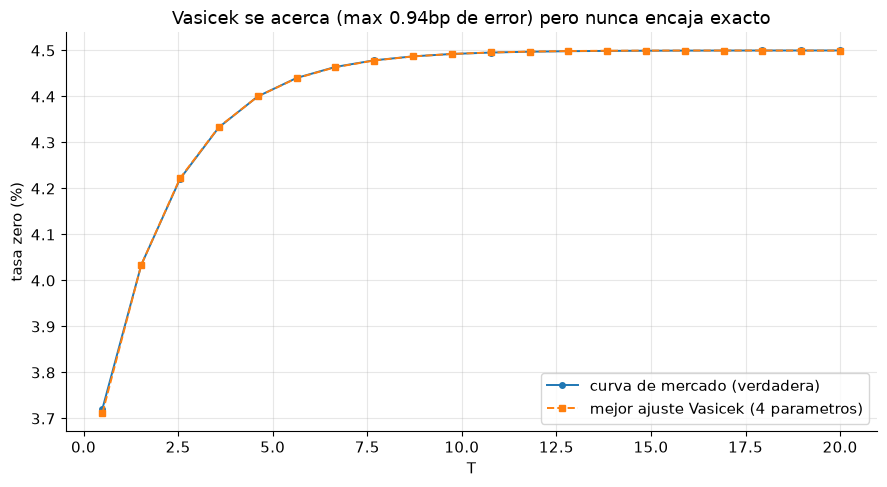

In [4]:
test_maturities = np.linspace(0.5, 20.0, 20)
target_prices = nelson_siegel_df(test_maturities)


def vasicek_residuals(params):
    kappa_, theta_, sigma_, r0_ = params
    if kappa_ <= 0.0 or sigma_ <= 0.0:
        return np.full_like(test_maturities, 1e3)
    return np.array([vasicek_bond(r0_, kappa_, theta_, sigma_, T) for T in test_maturities]) - target_prices


fit = least_squares(vasicek_residuals, x0=[0.3, 0.045, 0.015, 0.04],
                     bounds=([1e-4, -1.0, 1e-4, -1.0], [5.0, 1.0, 1.0, 1.0]))
kappa_fit, theta_fit, sigma_fit, r0_fit = fit.x
fitted_prices = np.array([vasicek_bond(r0_fit, kappa_fit, theta_fit, sigma_fit, T) for T in test_maturities])
zero_fit = -np.log(fitted_prices) / test_maturities
zero_true = -np.log(target_prices) / test_maturities
max_residual_df = np.max(np.abs(fit.fun))
max_residual_bp = np.max(np.abs(zero_fit - zero_true)) * 1e4

print(f"Mejor ajuste Vasicek: kappa={kappa_fit:.4f}, theta={theta_fit:.4f}, sigma={sigma_fit:.4f}, r0={r0_fit:.4f}")
print(f"Residual maximo en discount factor = {max_residual_df:.2e}")
print(f"Residual maximo en tasa zero = {max_residual_bp:.4f} bp  (no es cero: Vasicek no puede encajar exacto)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(test_maturities, zero_true * 1e2, "o-", ms=4, label="curva de mercado (verdadera)")
ax.plot(test_maturities, zero_fit * 1e2, "s--", ms=4, label="mejor ajuste Vasicek (4 parametros)")
ax.set_xlabel("T"); ax.set_ylabel("tasa zero (%)")
ax.set_title(f"Vasicek se acerca (max {max_residual_bp:.2f}bp de error) pero nunca encaja exacto")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Hull-White: reversión dependiente del tiempo, fit exacto

Hull-White (1990) generaliza Vasicek dejando que el nivel de reversión dependa del tiempo, $dr_t=\kappa(\theta(t)-r_t)dt+\sigma dW_t$, y eligiendo $\theta(t)$ **precisamente** para que el bono del modelo reproduzca la curva de mercado en todo vencimiento. La derivación es idéntica a la de Vasicek (mismo *ansatz* afín, mismas ODEs para $A,B$ salvo que ahora $\theta(t)$ entra dentro de una integral), y el resultado se puede escribir **sin pasar por $\theta(t)$ explícito**, directamente en términos de la curva de mercado observada $P^M(0,\cdot)$ y su forward instantáneo $f^M(0,t)=-\partial_t\ln P^M(0,t)$:
$$
\boxed{\;P^{HW}(t,T) = \frac{P^M(0,T)}{P^M(0,t)}\exp\!\left[B(t,T)f^M(0,t) - \frac{\sigma^2}{4\kappa}B(t,T)^2\big(1-e^{-2\kappa t}\big)\right]e^{-B(t,T)r_t}\;}, \qquad B(t,T)=\frac{1-e^{-\kappa(T-t)}}{\kappa}.
$$
En $t=0$, $r_0=f^M(0,0)$ y la fórmula se reduce **exactamente** a $P^{HW}(0,T)=P^M(0,T)$ para todo $T$ — el fit es una identidad algebraica, no un ajuste numérico. Ésta es la forma que de verdad se usa en producción: nunca hace falta calcular $\theta(t)$ explícitamente, sólo la curva de mercado y su forward instantáneo.

Hull-White exact fit: residual maximo en discount factor = 1.11e-16
  (Vasicek dejaba 4.61e-05 -- Hull-White es 4e+11x mas exacto)


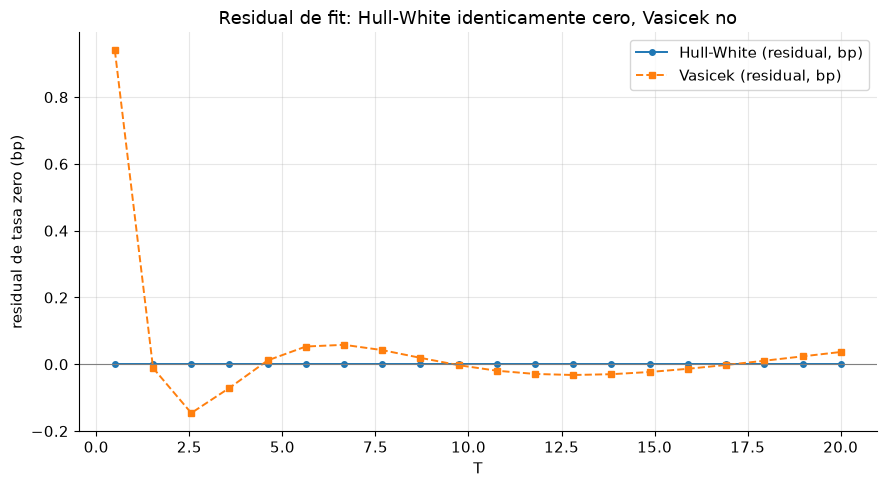

In [5]:
def hull_white_bond(t, T, r_t, P0t, P0T, f0t, kappa, sigma):
    '''Hull-White bond price via the market curve (Section 4) -- no explicit theta(t) needed.'''
    B = (1.0 - np.exp(-kappa * (T - t))) / kappa
    A_over_P = (P0T / P0t) * np.exp(B * f0t - sigma**2 / (4 * kappa) * B**2 * (1.0 - np.exp(-2 * kappa * t)))
    return A_over_P * np.exp(-B * r_t)


def instantaneous_forward(t, eps=1e-6):
    '''f^M(0,t) = -d/dt ln P^M(0,t), central difference (Section 4).'''
    return (np.log(nelson_siegel_df(t - eps)) - np.log(nelson_siegel_df(t + eps))) / (2.0 * eps)


kappa_hw, sigma_hw = 0.05, 0.01
r0_hw = instantaneous_forward(1e-6)

hw_prices = np.array([hull_white_bond(0.0, T, r0_hw, 1.0, nelson_siegel_df(T), r0_hw, kappa_hw, sigma_hw)
                       for T in test_maturities])
max_residual_hw = np.max(np.abs(hw_prices - target_prices))

print(f"Hull-White exact fit: residual maximo en discount factor = {max_residual_hw:.2e}")
print(f"  (Vasicek dejaba {max_residual_df:.2e} -- Hull-White es {max_residual_df/max(max_residual_hw,1e-300):.0e}x mas exacto)")

fig, ax = plt.subplots(figsize=(9, 5))
zero_hw = -np.log(hw_prices) / test_maturities
ax.plot(test_maturities, (zero_true - zero_hw) * 1e4, "o-", ms=4, label="Hull-White (residual, bp)")
ax.plot(test_maturities, (zero_true - zero_fit) * 1e4, "s--", ms=4, label="Vasicek (residual, bp)")
ax.axhline(0.0, color="gray", lw=0.8)
ax.set_xlabel("T"); ax.set_ylabel("residual de tasa zero (bp)")
ax.set_title("Residual de fit: Hull-White identicamente cero, Vasicek no")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Demo 3 — simulación bajo Hull-White y consistencia con el bono cerrado

Simulamos trayectorias de $r_t$ bajo Hull-White (usando el mismo esquema de Euler que 1.4, con el drift $\theta(t)$ recuperado implícitamente de la curva vía el mismo truco de no calcularlo explícito — se simula directamente la ecuación con $\kappa(\theta(t)-r_t)=\partial_tf^M(0,t)+\kappa f^M(0,t)+\tfrac{\sigma^2}{2\kappa}(1-e^{-2\kappa t})$, la forma cerrada del drift en términos de la curva) y verificamos que el bono promedio simulado desde $t=0$ coincide con la fórmula cerrada.

In [6]:
def hw_drift_theta_term(t, kappa, sigma, eps=1e-4):
    '''kappa*theta(t) recovered from the market curve (Section 5): d/dt f^M(0,t) + kappa*f^M(0,t)
    + sigma^2/(2 kappa)*(1-e^{-2 kappa t}).'''
    df_dt = (instantaneous_forward(t + eps) - instantaneous_forward(t - eps)) / (2 * eps)
    return df_dt + kappa * instantaneous_forward(t) + sigma**2 / (2 * kappa) * (1.0 - np.exp(-2 * kappa * t))


T_sim = 5.0
n_steps_sim = 250
dt_sim = T_sim / n_steps_sim
t_grid = np.linspace(0.0, T_sim, n_steps_sim + 1)
kappa_theta_grid = np.array([hw_drift_theta_term(max(t, 1e-4), kappa_hw, sigma_hw) for t in t_grid[:-1]])

n_paths_hw = 100_000
Z = rng.standard_normal((n_paths_hw, n_steps_sim))
r_paths = np.empty((n_paths_hw, n_steps_sim + 1))
r_paths[:, 0] = r0_hw
for k in range(n_steps_sim):
    r_paths[:, k + 1] = (r_paths[:, k] + (kappa_theta_grid[k] - kappa_hw * r_paths[:, k]) * dt_sim
                         + sigma_hw * np.sqrt(dt_sim) * Z[:, k])

integral_r_hw = np.sum((r_paths[:, :-1] + r_paths[:, 1:]) / 2.0 * dt_sim, axis=1)
discounted_hw = np.exp(-integral_r_hw)
mc_hw_mean, mc_hw_se = discounted_hw.mean(), discounted_hw.std(ddof=1) / np.sqrt(n_paths_hw)
closed_hw_T5 = nelson_siegel_df(T_sim)   # por construccion, el HW en t=0 reproduce la curva de mercado exacta

print(f"Hull-White MC (n={n_paths_hw:,})  = {mc_hw_mean:.8f} +- {3*mc_hw_se:.6f} (3 SE)")
print(f"Curva de mercado P(0,{T_sim})     = {closed_hw_T5:.8f}")
print(f"|MC - mercado| / SE = {abs(mc_hw_mean-closed_hw_T5)/mc_hw_se:.3f} "
      f"(<=3? {abs(mc_hw_mean-closed_hw_T5)/mc_hw_se <= 3.0})")

Hull-White MC (n=100,000)  = 0.80159872 +- 0.000450 (3 SE)
Curva de mercado P(0,5.0)     = 0.80180026
|MC - mercado| / SE = 1.344 (<=3? True)


## 6. Validación

1. **Vasicek cerrado vs MC**: dentro de 3 SE con $n=2\times10^5$.
2. **Vasicek no encaja exacto**: el residuo del mejor ajuste por mínimos cuadrados es estrictamente positivo (`> 1e-6` en discount factor) — no cero, aunque pequeño.
3. **Hull-White encaja exacto**: residuo `< 1e-10` en discount factor sobre los mismos 20 vencimientos — una identidad algebraica, y **al menos** $10^3$ veces más exacto que el mejor Vasicek.
4. **Hull-White MC vs curva de mercado**: dentro de 3 SE.
5. **Cross-check QuantLib**: `hull_white_bond` propio vs `ql.HullWhite` model `discountBond(t,T,r_t)` para varios `(t,T,r_t)` no triviales, `atol=1e-8`.

In [7]:
import QuantLib as ql

# 1. Vasicek cerrado vs MC
z_vasicek_mc = abs(mc_mean - vasicek_closed) / mc_se
print(f"Vasicek MC vs cerrado: z = {z_vasicek_mc:.3f} (<=3? {z_vasicek_mc <= 3.0})")
assert z_vasicek_mc <= 3.0

# 2. Vasicek no encaja exacto
print(f"Vasicek residual maximo = {max_residual_df:.2e} (>1e-6? {max_residual_df > 1e-6})")
assert max_residual_df > 1e-6

# 3. Hull-White encaja exacto
print(f"Hull-White residual maximo = {max_residual_hw:.2e} (<1e-10? {max_residual_hw < 1e-10})")
assert max_residual_hw < 1e-10
ratio_exactness = max_residual_df / max(max_residual_hw, 1e-300)
print(f"Hull-White es {ratio_exactness:.2e}x mas exacto que el mejor Vasicek (>=1e3? {ratio_exactness >= 1e3})")
assert ratio_exactness >= 1e3

# 4. Hull-White MC vs mercado
z_hw_mc = abs(mc_hw_mean - closed_hw_T5) / mc_hw_se
print(f"Hull-White MC vs mercado: z = {z_hw_mc:.3f} (<=3? {z_hw_mc <= 3.0})")
assert z_hw_mc <= 3.0

# 5. QuantLib cross-check
eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()
times_grid = np.linspace(1 / 365, 20.0, 400)
dfs_grid = nelson_siegel_df(times_grid)
dates_grid = [eval_date] + [eval_date + ql.Period(int(round(t * 365)), ql.Days) for t in times_grid]
discounts_grid = [1.0] + list(dfs_grid)
curve_ql = ql.DiscountCurve(dates_grid, discounts_grid, day_count)
curve_ql.enableExtrapolation()
curve_handle = ql.YieldTermStructureHandle(curve_ql)
model_ql = ql.HullWhite(curve_handle, kappa_hw, sigma_hw)

def ql_curve_forward(t, eps=1e-5):
    # forward instantaneo de la MISMA curva discreta que usa QuantLib, no el analitico de Nelson-Siegel
    # (con solo 400 nodos, la interpolacion propia de QuantLib difiere ligeramente de la formula NS exacta;
    # usar cada uno con su propio forward evita comparar dos curvas sutilmente distintas)
    return -(np.log(curve_ql.discount(t + eps)) - np.log(curve_ql.discount(t - eps))) / (2 * eps)


max_diff_ql = 0.0
for t_q, T_q, r_q in [(1.0, 3.0, 0.045), (2.0, 7.0, 0.035), (0.5, 10.0, 0.05)]:
    ql_price = model_ql.discountBond(t_q, T_q, r_q)
    P0t_q, P0T_q, f0t_q = curve_ql.discount(t_q), curve_ql.discount(T_q), ql_curve_forward(t_q)
    my_price = hull_white_bond(t_q, T_q, r_q, P0t_q, P0T_q, f0t_q, kappa_hw, sigma_hw)
    diff = abs(ql_price - my_price)
    max_diff_ql = max(max_diff_ql, diff)
    print(f"  (t={t_q},T={T_q},r={r_q}): QuantLib={ql_price:.10f} propio={my_price:.10f} diff={diff:.2e}")
print(f"max|diff| propio vs QuantLib = {max_diff_ql:.2e} (atol 1e-8? {max_diff_ql < 1e-8})")
assert max_diff_ql < 1e-8

print()
print("Validacion completa: 5/5 dentro de tolerancia.")

Vasicek MC vs cerrado: z = 1.061 (<=3? True)
Vasicek residual maximo = 4.61e-05 (>1e-6? True)
Hull-White residual maximo = 1.11e-16 (<1e-10? True)
Hull-White es 4.15e+11x mas exacto que el mejor Vasicek (>=1e3? True)
Hull-White MC vs mercado: z = 1.344 (<=3? True)
  (t=1.0,T=3.0,r=0.045): QuantLib=0.9101202077 propio=0.9101202077 diff=1.79e-12
  (t=2.0,T=7.0,r=0.035): QuantLib=0.8225594399 propio=0.8225594399 diff=5.05e-12
  (t=0.5,T=10.0,r=0.05): QuantLib=0.6002521356 propio=0.6002521356 diff=3.68e-12
max|diff| propio vs QuantLib = 5.05e-12 (atol 1e-8? True)

Validacion completa: 5/5 dentro de tolerancia.


## Referencias

- Vasicek, O. (1977). *An Equilibrium Characterization of the Term Structure*. Journal of Financial Economics, 5(2), 177-188.
- Hull, J.C. & White, A. (1990). *Pricing Interest-Rate-Derivative Securities*. Review of Financial Studies, 3(4), 573-592.
- Brigo, D. & Mercurio, F. (2006). *Interest Rate Models — Theory and Practice*, 2nd ed., Springer, cap. 3.
- Hull, J.C. *Options, Futures, and Other Derivatives*, 10th ed., cap. 32 (modelos de un factor).